In [3]:
# parametres a changer
variante = "rgb"                  # "rgb", "nb", "contours"
normalisation = "non_normalisee"  # "normalisee" ou "non_normalisee"
epochs = 30
lr = 0.1

In [4]:
# compile linear_model.c puis lance le binaire
import subprocess
from pathlib import Path

# on remonte jusqu'a la racine du projet (le dossier qui contient preprocessing)
racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

chemin_c = racine / "models" / "lineaire" / "linear_model.c"
chemin_exec = racine / "models" / "lineaire" / "linear_model"

subprocess.check_call(["gcc", str(chemin_c), "-o", str(chemin_exec), "-lm"], cwd=str(racine))

base = racine / "datasets" / "transformed" / variante / normalisation
cmd = [
    str(chemin_exec),
    str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
    str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
    str(epochs), str(lr),
]

sortie = subprocess.check_output(cmd, text=True, cwd=str(racine))
print(sortie)

Chargé train: n=1200, d=49152
Chargé test : n=301, d=49152
Entraînement perceptron multi-classes (K=3), epochs=30, lr=0.1000
epoch 1 train 0.340 test 0.326
epoch 2 train 0.404 test 0.362
epoch 3 train 0.358 test 0.339
epoch 4 train 0.372 test 0.339
epoch 5 train 0.463 test 0.385
epoch 6 train 0.403 test 0.352
epoch 7 train 0.423 test 0.355
epoch 8 train 0.461 test 0.379
epoch 9 train 0.467 test 0.385
epoch 10 train 0.481 test 0.369
epoch 11 train 0.600 test 0.462
epoch 12 train 0.380 test 0.336
epoch 13 train 0.401 test 0.349
epoch 14 train 0.451 test 0.372
epoch 15 train 0.393 test 0.339
epoch 16 train 0.482 test 0.395
epoch 17 train 0.440 test 0.359
epoch 18 train 0.500 test 0.392
epoch 19 train 0.458 test 0.382
epoch 20 train 0.409 test 0.339
epoch 21 train 0.423 test 0.349
epoch 22 train 0.534 test 0.402
epoch 23 train 0.641 test 0.455
epoch 24 train 0.628 test 0.452
epoch 25 train 0.417 test 0.355
epoch 26 train 0.618 test 0.445
epoch 27 train 0.525 test 0.399
epoch 28 train 0.488

In [5]:
# on recupere les accuracy et la confusion depuis le texte du C
epochs_liste = []
acc_train = []
acc_test = []
confusion = None

lignes = sortie.strip().splitlines()
for ligne in lignes:
    if ligne.startswith("epoch "):
        m = ligne.split()   # epoch 3 train 0.612 test 0.470
        epochs_liste.append(int(m[1]))
        acc_train.append(float(m[3]))
        acc_test.append(float(m[5]))

for i, ligne in enumerate(lignes):
    if ligne.strip() == "confusion":
        confusion = [[int(x) for x in lignes[i + 1 + j].split()] for j in range(3)]
        break

print("acc_test finale:", acc_test[-1])
print("confusion:", confusion)

acc_test finale: 0.468
confusion: [[5, 74, 19], [1, 82, 23], [2, 41, 54]]


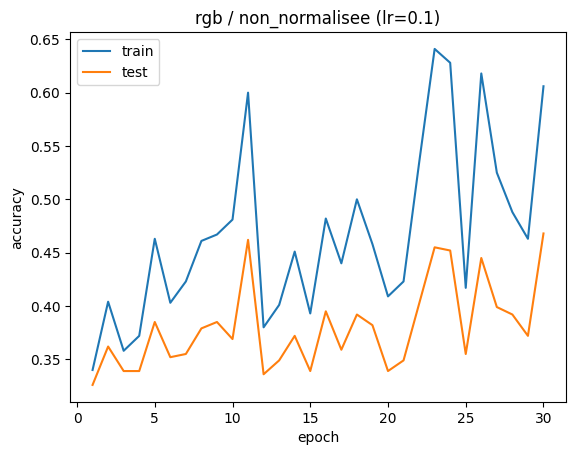

In [6]:
# courbe train vs test (pour voir le surapprentissage)
import matplotlib.pyplot as plt

plt.plot(epochs_liste, acc_train, label="train")
plt.plot(epochs_liste, acc_test, label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"{variante} / {normalisation} (lr={lr})")
plt.legend()
plt.show()

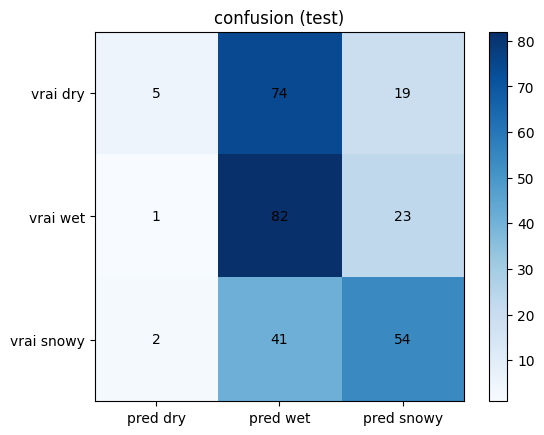

In [7]:
# matrice de confusion sur le test
plt.imshow(confusion, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], ["pred dry", "pred wet", "pred snowy"])
plt.yticks([0, 1, 2], ["vrai dry", "vrai wet", "vrai snowy"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, confusion[i][j], ha="center", va="center")
plt.title("confusion (test)")
plt.show()

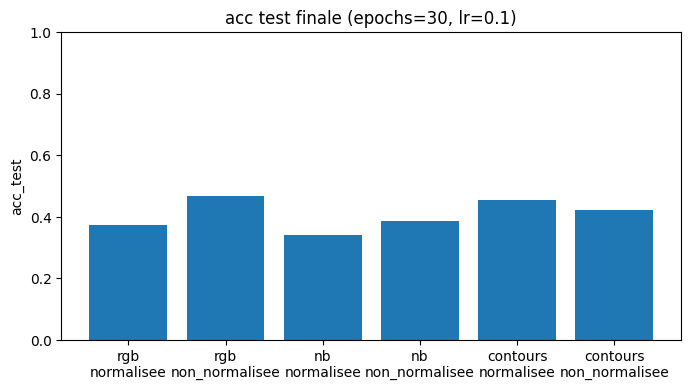

In [8]:
# meme modele sur les 6 variantes, on compare l'acc test finale
def acc_test_finale(variante, normalisation):
    base = racine / "datasets" / "transformed" / variante / normalisation
    cmd = [
        str(chemin_exec),
        str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
        str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
        str(epochs), str(lr),
    ]
    sortie = subprocess.check_output(cmd, text=True, cwd=str(racine))
    derniere = None
    for ligne in sortie.strip().splitlines():
        if ligne.startswith("epoch "):
            derniere = float(ligne.split()[5])
    return derniere

labels = []
valeurs = []
for v in ["rgb", "nb", "contours"]:
    for norm in ["normalisee", "non_normalisee"]:
        labels.append(f"{v}\n{norm}")
        valeurs.append(acc_test_finale(v, norm))

plt.figure(figsize=(8, 4))
plt.bar(labels, valeurs)
plt.ylabel("acc_test")
plt.title(f"acc test finale (epochs={epochs}, lr={lr})")
plt.ylim(0, 1)
plt.show()